In [2]:
import gzip
import os
import sys
import urllib
import matplotlib.image as mpimg
from PIL import Image
%matplotlib inline
import matplotlib.image as mpimg
import numpy as np
import matplotlib.pyplot as plt
import os, sys
from PIL import Image

import code

import tensorflow.python.platform
from tensorflow.keras import datasets, layers, models
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import keras

import numpy
import tensorflow as tf

## Learning to label patches

In [8]:
# Set image patch size in pixels
# IMG_PATCH_SIZE should be a multiple of 4
# image size should be an integer multiple of this number!
IMG_PATCH_SIZE = 16

# Extract patches from a given image
def img_crop(im, w, h):
    list_patches = []
    imgwidth = im.shape[0]
    imgheight = im.shape[1]
    is_2d = len(im.shape) < 3
    for i in range(0, imgheight, h):
        for j in range(0, imgwidth, w):
            if is_2d:
                im_patch = im[j : j + w, i : i + h]
            else:
                im_patch = im[j : j + w, i : i + h, :]
            list_patches.append(im_patch)
    return list_patches


def extract_data(filename, num_images):
    """Extract the images into a 4D tensor [image index, y, x, channels].
    Values are rescaled from [0, 255] down to [-0.5, 0.5].
    """
    imgs = []
    gt_imgs = []
    for i in range(1, num_images + 1):
        imageid = "satImage_%.3d" % i
        image_filename = filename + imageid + ".png"
        if os.path.isfile(image_filename):
            #print("Loading " + image_filename)
            img = mpimg.imread(image_filename)
            imgs.append(img)
        else:
            print("File " + image_filename + " does not exist")

    num_images = len(imgs)
    IMG_WIDTH = imgs[0].shape[0]
    IMG_HEIGHT = imgs[0].shape[1]
    N_PATCHES_PER_IMAGE = (IMG_WIDTH / IMG_PATCH_SIZE) * (IMG_HEIGHT / IMG_PATCH_SIZE)

    img_patches = [
        img_crop(imgs[i], IMG_PATCH_SIZE, IMG_PATCH_SIZE) for i in range(num_images)
    ]
    data = [
        img_patches[i][j]
        for i in range(len(img_patches))
        for j in range(len(img_patches[i]))
    ]

    return numpy.asarray(data)

# Assign a label to a patch v
def value_to_class(v):
    foreground_threshold = 0.25  # percentage of pixels > 1 required to assign a foreground label to a patch
    df = numpy.sum(v)
    if df > foreground_threshold:  # road
        return [0, 1]
    else:  # bgrd
        return [1, 0]


# Extract label images
def extract_labels(filename, num_images):
    """Extract the labels into a 1-hot matrix [image index, label index]."""
    gt_imgs = []
    for i in range(1, num_images + 1):
        imageid = "satImage_%.3d" % i
        image_filename = filename + imageid + ".png"
        if os.path.isfile(image_filename):
            #print("Loading " + image_filename)
            img = mpimg.imread(image_filename)
            gt_imgs.append(img)
        else:
            print("File " + image_filename + " does not exist")

    num_images = len(gt_imgs)
    gt_patches = [
        img_crop(gt_imgs[i], IMG_PATCH_SIZE, IMG_PATCH_SIZE) for i in range(num_images)
    ]
    data = numpy.asarray(
        [
            gt_patches[i][j]
            for i in range(len(gt_patches))
            for j in range(len(gt_patches[i]))
        ]
    )
    labels = numpy.asarray(
        [value_to_class(numpy.mean(data[i])) for i in range(len(data))]
    )

    # Convert to dense 1-hot representation.
    return labels.astype(numpy.float32)

In [9]:
TRAINING_SIZE = 100  # Size of the training data

train_labels_filename = 'training/groundtruth/'
labels = extract_labels(train_labels_filename, TRAINING_SIZE)
print(len(labels))


62500


In [10]:
TRAINING_SIZE = 100  # Size of the training data

def main():
    data_dir = "training/"
    train_data_filename = data_dir + "images/"
    train_labels_filename = data_dir + "groundtruth/"

    # Extract it into numpy arrays.
    data = extract_data(train_data_filename, TRAINING_SIZE)
    labels = extract_labels(train_labels_filename, TRAINING_SIZE)

    c0 = 0  # bgrd
    c1 = 0  # road
    for i in range(len(labels)):  # Iterate over each patch
        if labels[i][0] == 1:     # ie patch is background
            c0 = c0 + 1
        else:
            c1 = c1 + 1
    print("Number of data points per class: c0 = " + str(c0) + " c1 = " + str(c1))
    
    print("Balancing training data...")
    min_c = min(c0, c1)
    idx0 = [i for i, j in enumerate(labels) if j[0] == 1]     # Get the indices of the patches that are background
    idx1 = [i for i, j in enumerate(labels) if j[1] == 1]     # Get the indices of the patches that are road
    new_indices = idx0[0:min_c] + idx1[0:min_c]
    print(len(new_indices))
    print(data.shape)
    data = data[new_indices, :, :, :]
    labels = labels[new_indices]
    
    c0 = 0
    c1 = 0
    for i in range(len(labels)):
        if labels[i][0] == 1:
            c0 = c0 + 1
        else:
            c1 = c1 + 1
    print("Number of data points per class: c0 = " + str(c0) + " c1 = " + str(c1))
    
    return data, labels

In [11]:
data, labels = main()

Number of data points per class: c0 = 46309 c1 = 16191
Balancing training data...
32382
(62500, 16, 16, 3)
Number of data points per class: c0 = 16191 c1 = 16191


Label: [1. 0.]


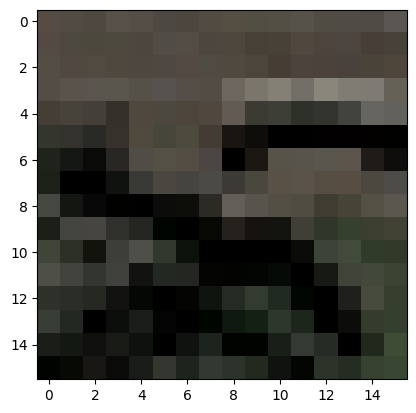

In [12]:
def display_example_images(train_data, train_labels):
    # Display the first image and the label
    image = train_data[0]
    label = train_labels[0]
    plt.imshow(image)
    print("Label: " + str(label))
        
display_example_images(data, labels)

In [13]:
# Change the labels to one-hot encoding
labels = np.array([1 if np.array_equal(label, np.array([1, 0])) else 0 for label in labels])

# Shuffle the data
np.random.seed(10)
shuffle = list(range(len(data)))
np.random.shuffle(shuffle)
data_shuffled = data[shuffle]
labels_shuffled = labels[shuffle]

# Split the data into training and validation sets
VALIDATION_SIZE = len(data) // 5
validation_data = data[:VALIDATION_SIZE, :, :, :] 
validation_labels = labels[:VALIDATION_SIZE]
train_data = data[VALIDATION_SIZE:, :, :, :]
train_labels = labels[VALIDATION_SIZE:]

print("Training data shape: " + str(train_data.shape), "Validation data shape: " + str(validation_data.shape))
print("Training labels shape: " + str(train_labels.shape), "Validation labels shape: " + str(validation_labels.shape))

Training data shape: (25906, 16, 16, 3) Validation data shape: (6476, 16, 16, 3)
Training labels shape: (25906,) Validation labels shape: (6476,)


In [14]:
import tensorflow as tf
from tensorflow.keras import models, layers, regularizers

# Model definition
model = models.Sequential()

# Conv Layer 1
model.add(layers.Conv2D(
    filters=32, 
    kernel_size=(5, 5), 
    strides=(1, 1), 
    padding='same',
    activation='relu',
    kernel_initializer=tf.keras.initializers.TruncatedNormal(stddev=0.1, seed=42),
    input_shape=(16, 16, 3)
))  # Matches conv1_weights
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='same'))

# Conv Layer 2
model.add(layers.Conv2D(
    filters=64,
    kernel_size=(5, 5),
    strides=(1, 1),
    padding='same',
    activation='relu',
    kernel_initializer=tf.keras.initializers.TruncatedNormal(stddev=0.1, seed=42),
))  # Matches conv2_weights
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='same'))

# Flattening for Fully Connected Layers
model.add(layers.Flatten())

# Fully Connected Layer 1
model.add(layers.Dense(
    units=512,
    activation='relu',
    kernel_regularizer=regularizers.L2(5e-4),
    kernel_initializer=tf.keras.initializers.TruncatedNormal(stddev=0.1, seed=42),
    bias_initializer=tf.keras.initializers.Constant(0.1),
))

# Fully Connected Layer 2 (Output)
model.add(layers.Dense(
    units=1,  # Binary classification
    activation='sigmoid',
    kernel_regularizer=regularizers.L2(5e-4),
    kernel_initializer=tf.keras.initializers.TruncatedNormal(stddev=0.1, seed=42),
    bias_initializer=tf.keras.initializers.Constant(0.1),
))

# Compile the model
initial_learning_rate = 0.001
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=1000,  # Adjust according to dataset size
    decay_rate=0.95,
    staircase=True
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Model summary
model.summary()

# Training the model
history = model.fit(
    train_data, train_labels,
    epochs=30,
    validation_data=(validation_data, validation_labels),
    batch_size=32
)


c:\Users\Noé\Documents\EPFL\Machine Learning\project2\project2-AAA\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 579,009 (2.21 MB)

 Trainable params: 579,009 (2.21 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
810/810 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.6391 - loss: 1.6164 - val_accuracy: 0.2528 - val_loss: 1.0586
Epoch 2/30
810/810 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7107 - loss: 0.6971 - val_accuracy: 0.2514 - val_loss: 1.0629
Epoch 3/30
810/810 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7418 - loss: 0.5717 - val_accuracy: 0.5902 - val_loss: 0.6805
Epoch 4/30
810/810 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7768 - loss: 0.5033 - val_accuracy: 0.5459 - val_loss: 0.7620
Epoch 5/30
810/810 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7916 - loss: 0.4761 - val_accuracy: 0.5840 - val_loss: 0.7140
Epoch 6/30
810/810 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8123 - loss: 0.4462 - val_accuracy: 0.6407 - val_loss: 0.6600
Epoch 7/30
810/810 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8195 - loss: 0.4286 - val_accuracy: 0.6850 - val_loss: 0.5987
Epoch 8/30
810/810 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8332 - loss: 0.4101 - val_accuracy: 0.

KeyboardInterrupt: 

203/203 - 0s - 2ms/step - accuracy: 0.6742 - loss: 1.3752


[1.37517249584198, 0.6741815805435181]

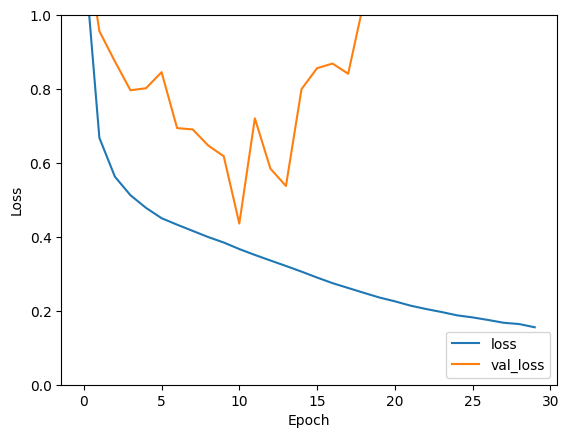

In [ ]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 1])
plt.legend(loc='lower right')

model.evaluate(validation_data,  validation_labels, verbose=2)

## Learning to superpose

In [3]:
def extract_data_wo_patches(filename, num_images):
    """Extract the images into a 4D tensor [image index, y, x, channels].
    Values are rescaled from [0, 255] down to [-0.5, 0.5].
    """
    imgs = []
    for i in range(1, num_images + 1):
        imageid = "satImage_%.3d" % i
        image_filename = filename + imageid + ".png"
        if os.path.isfile(image_filename):
            #print("Loading " + image_filename)
            img = mpimg.imread(image_filename)
            imgs.append(img)
        else:
            print("File " + image_filename + " does not exist")
            
    return numpy.asarray(imgs)

In [4]:
TRAINING_SIZE = 100  # Size of the training data

def main():
    data_dir = "training/"
    data_filename = data_dir + "images/"
    gt_filename = data_dir + "groundtruth/"

    # Extract it into numpy arrays.
    data = extract_data_wo_patches(data_filename, TRAINING_SIZE)
    labels = extract_data_wo_patches(gt_filename, TRAINING_SIZE)
    
    return data, labels


In [7]:
data, gt = main()
# Binarise the ground truth
gt > 0.25
data.shape, gt.shape

((100, 400, 400, 3), (100, 400, 400))

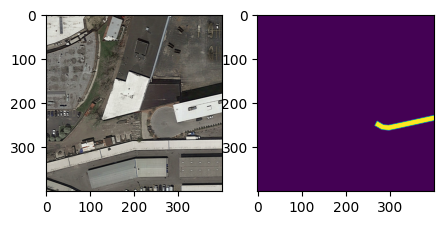

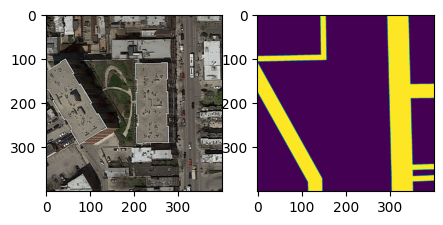

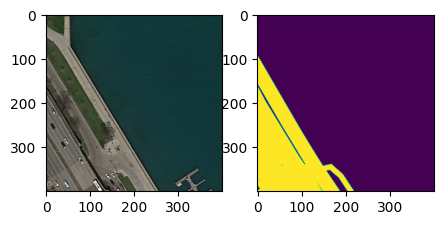

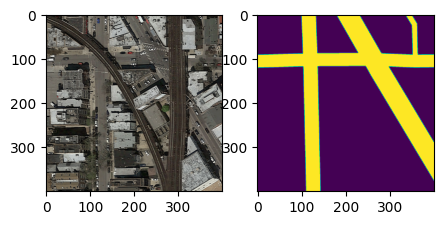

In [108]:
def display_example_images(data, gt, i):
    # Display the first image and the label
    image = data[i]
    road = gt[i]
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.subplot(1, 2, 2)
    plt.imshow(road)
    
i1 = 27
i2 = 87
i3 = 90
i4 = np.random.randint(0, 100)

plt.figure(figsize=(5, 5))
display_example_images(data, gt, i1)
plt.figure(figsize=(5, 5))
display_example_images(data, gt, i2)
plt.figure(figsize=(5, 5))
display_example_images(data, gt, i3)
plt.figure(figsize=(5, 5))
display_example_images(data, gt, i4)

# Discarding shity examples

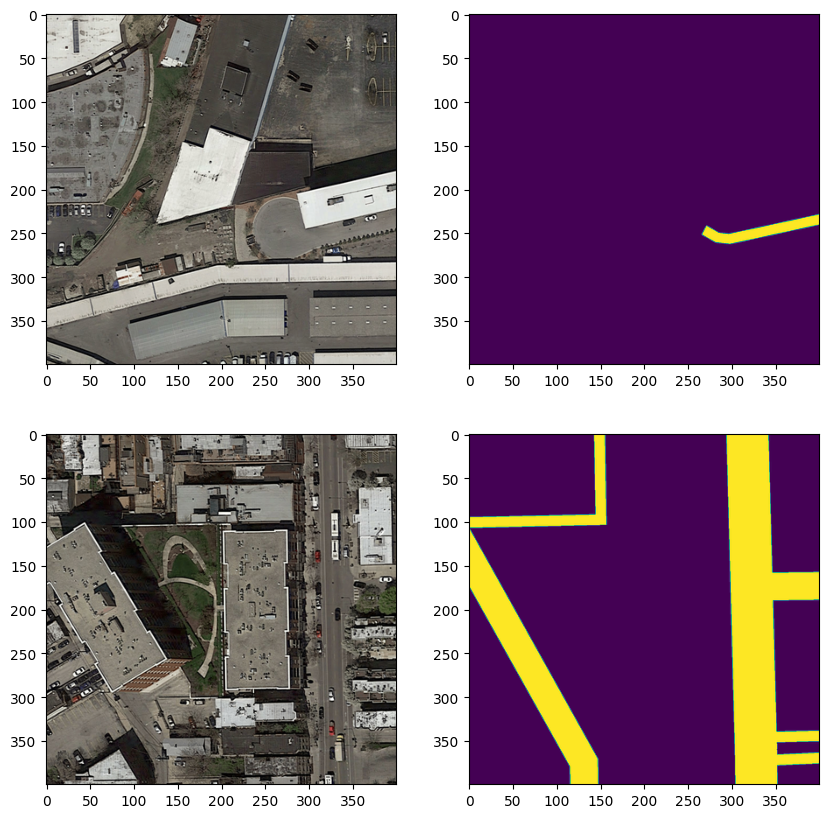

In [115]:
i1 = 27
i2 = 87
i3 = 90
i4 = 41

# Plot the two first images and their groundtruth
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.imshow(data[i1])
plt.subplot(2, 2, 2)
plt.imshow(gt[i1])
plt.subplot(2, 2, 3)
plt.imshow(data[i2])
plt.subplot(2, 2, 4)
plt.imshow(gt[i2])


In [9]:
# for each image, add its three rotated versions in data and gt
data_rot = np.zeros((4*len(data), 400, 400, 3))
gt_rot = np.zeros((4*len(data), 400, 400))

for i in range(len(data)):
    data_rot[4*i] = data[i]
    data_rot[4*i+1] = np.rot90(data[i])
    data_rot[4*i+2] = np.rot90(data_rot[4*i+1])
    data_rot[4*i+3] = np.rot90(data_rot[4*i+2])
    
    gt_rot[4*i] = gt[i]
    gt_rot[4*i+1] = np.rot90(gt[i])
    gt_rot[4*i+2] = np.rot90(gt_rot[4*i+1])
    gt_rot[4*i+3] = np.rot90(gt_rot[4*i+2])

print(data_rot.shape, gt_rot.shape)
# For each image, extract four 304x304 patches
n = len(data_rot)
data_patches = np.zeros((4*n, 304, 304, 3))
gt_patches = np.zeros((4*n, 304, 304))

for i in range(n):
    data_patches[i] = data_rot[i][0:304, 0:304, :]
    gt_patches[i] = gt_rot[i][0:304, 0:304]
    data_patches[n+i] = data_rot[i][96:400, 96:400, :]
    gt_patches[n+i] = gt_rot[i][96:400, 96:400]
    data_patches[2*n+i] = data_rot[i][0:304, 96:400, :]
    gt_patches[2*n+i] = gt_rot[i][0:304, 96:400]
    data_patches[3*n+i] = data_rot[i][96:400, 0:304, :]
    gt_patches[3*n+i] = gt_rot[i][96:400, 0:304]
    

NameError: name 'data' is not defined

In [ ]:

# Shuffle the data
np.random.seed(10)
shuffle = list(range(len(data_patches)))
np.random.shuffle(shuffle)
data_shuffled = data_patches[shuffle]
gt_shuffled = gt_patches[shuffle]

# Split the data into training and validation sets
VALIDATION_SIZE = len(data_shuffled) // 5
validation_data = data_shuffled[:VALIDATION_SIZE, :, :, :] 
validation_gt = gt_shuffled[:VALIDATION_SIZE]
train_data = data_shuffled[VALIDATION_SIZE:, :, :, :]
train_gt = gt_shuffled[VALIDATION_SIZE:]

print("Training data shape: " + str(train_data.shape), "Validation data shape: " + str(validation_data.shape))
print("Training labels shape: " + str(train_gt.shape), "Validation labels shape: " + str(validation_gt.shape))

Training data shape: (1280, 304, 304, 3) Validation data shape: (320, 304, 304, 3)
Training labels shape: (1280, 304, 304) Validation labels shape: (320, 304, 304)


In [12]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, BatchNormalization, Dropout
from tensorflow.keras.models import Model

def unet(input_size=(304, 304, 3)):
    inputs = Input(input_size)
    
    # Encoder
    c1 = Conv2D(8, (3, 3), activation='relu', padding='same')(inputs)
    c1 = BatchNormalization()(c1)
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(8, (3, 3), activation='relu', padding='same')(c1)
    c1 = BatchNormalization()(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    
    c2 = Conv2D(16, (3, 3), activation='relu', padding='same')(p1)
    c2 = BatchNormalization()(c2)
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(16, (3, 3), activation='relu', padding='same')(c2)
    c2 = BatchNormalization()(c2)
    p2 = MaxPooling2D((2, 2))(c2)
    
    c3 = Conv2D(32, (3, 3), activation='relu', padding='same')(p2)
    c3 = BatchNormalization()(c3)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(32, (3, 3), activation='relu', padding='same')(c3)
    c3 = BatchNormalization()(c3)
    p3 = MaxPooling2D((2, 2))(c3)
    
    c4 = Conv2D(64, (3, 3), activation='relu', padding='same')(p3)
    c4 = BatchNormalization()(c4)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(64, (3, 3), activation='relu', padding='same')(c4)
    c4 = BatchNormalization()(c4)
    p4 = MaxPooling2D((2, 2))(c4)
    
    # Bottleneck
    c5 = Conv2D(128, (3, 3), activation='relu', padding='same')(p4)
    c5 = BatchNormalization()(c5)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(128, (3, 3), activation='relu', padding='same')(c5)
    c5 = BatchNormalization()(c5)
    
    # Decoder
    u6 = UpSampling2D((2, 2))(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(64, (3, 3), activation='relu', padding='same')(u6)
    c6 = BatchNormalization()(c6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(64, (3, 3), activation='relu', padding='same')(c6)
    c6 = BatchNormalization()(c6)
    
    u7 = UpSampling2D((2, 2))(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(32, (3, 3), activation='relu', padding='same')(u7)
    c7 = BatchNormalization()(c7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(32, (3, 3), activation='relu', padding='same')(c7)
    c7 = BatchNormalization()(c7)
    
    u8 = UpSampling2D((2, 2))(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32, (3, 3), activation='relu', padding='same')(u8)
    c8 = BatchNormalization()(c8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv2D(32, (3, 3), activation='relu', padding='same')(c8)
    c8 = BatchNormalization()(c8)
    
    u9 = UpSampling2D((2, 2))(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(16, (3, 3), activation='relu', padding='same')(u9)
    c9 = BatchNormalization()(c9)
    c9 = Dropout(0.1)(c9)
    
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)
    
    model = Model(inputs, outputs, name="U-NET")
    return model

In [13]:
# Create the model
model = unet(input_size=(304, 304, 3))

model.summary()

Model: "U-NET"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 304, 304, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 304, 304, 8)          224       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 304, 304, 8)          32        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 dropout (Dropout)           (None, 304, 304, 8)          0         ['batch_normalization[0][0

In [14]:
# Method to calculate Intersection over Union Accuracy Coefficient
def iou_coef(y_true, y_pred, smooth=1e-6):
    intersection = tensorflow.reduce_sum(y_true * y_pred)
    union = tensorflow.reduce_sum(y_true) + tensorflow.reduce_sum(y_pred) - intersection
    
    return (intersection + smooth) / (union + smooth)

# Method to calculate Dice Accuracy Coefficient
def dice_coef(y_true, y_pred, smooth=1e-6):
    intersection = tensorflow.reduce_sum(y_true * y_pred)
    total = tensorflow.reduce_sum(y_true) + tensorflow.reduce_sum(y_pred)
    
    return (2. * intersection + smooth) / (total + smooth)

# Method to calculate Dice Loss
def soft_dice_loss(y_true, y_pred):
    return 1-dice_coef(y_true, y_pred)

In [22]:
# Compile the model
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,     # maybe 0.001 is better
    decay_steps=1000,
    decay_rate=0.95,
    staircase=True
)

# Defining optimizer
opt = keras.optimizers.Adam(learning_rate=lr_schedule)
model.compile(
    optimizer=opt,
    loss=soft_dice_loss,
    metrics=[iou_coef, dice_coef]
)

# Training the model
history = model.fit(
    train_data, train_gt,
    epochs=30,
    batch_size=32,
    validation_data=(validation_data, validation_gt),
    verbose=1
)

MemoryError: Unable to allocate 1.32 GiB for an array with shape (1280, 304, 304, 3) and data type float32

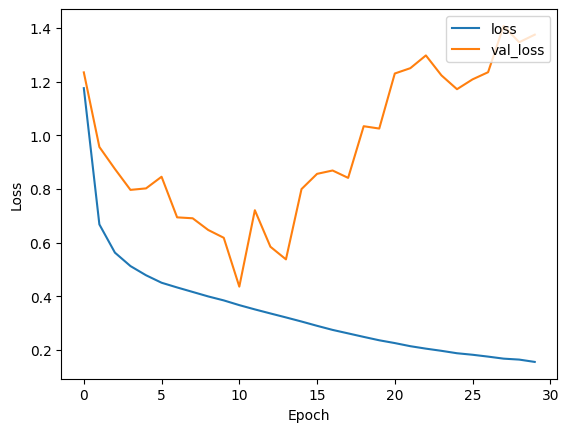

In [23]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')  
plt.legend(loc='upper right')

In [24]:
# Predictions
predictions = model.predict(validation_data)
predictions.shape

: 

In [1]:
# Display the first image and the label
i = 6
image = validation_data[i]
road = validation_gt[i]
prediction = predictions[i]
plt.subplot(1, 3, 1)
plt.imshow(image)
plt.subplot(1, 3, 2)
plt.imshow(road)
plt.subplot(1, 3, 3)
plt.imshow(prediction)


NameError: name 'validation_data' is not defined

1/1 [==============================] - 0s 295ms/step


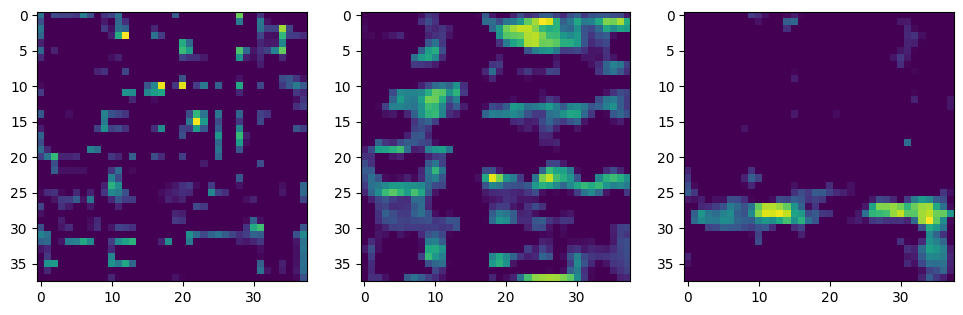

In [50]:
# Visualize the output of the first layer of the model
from tensorflow.keras.models import Model

# Extract the first layer of the model
layer_outputs = [layer.output for layer in model.layers]
activation_model = Model(inputs=model.input, outputs=layer_outputs)

# Get the activations of the first layer
activations = activation_model.predict(validation_data[0].reshape(1, 304, 304, 3))

# Display the first 4 channels of the activations
plt.figure(figsize=(16, 16))
for i in range(3):
    plt.subplot(1, 4, i + 1)
    plt.imshow(activations[20][0, :, :, i], cmap='viridis')


## Learn to epurate the prediction to predict the labels

In [15]:

IMG_PATCH_SIZE = 16

# Extract 16x16 patches from a given image
def img_crop(im, w, h):
    list_patches = []
    imgwidth = im.shape[0]
    imgheight = im.shape[1]
    is_2d = len(im.shape) < 3
    for j in range(0, imgheight, h):
        for i in range(0, imgwidth, w):
            if is_2d:
                im_patch = im[j : j + w, i : i + h]
            else:
                im_patch = im[j : j + w, i : i + h, :]
            list_patches.append(im_patch)
    return list_patches

# Extract patches from the training data
def split_patches(gt):
    num_images = len(gt)
    img_patches = [
        img_crop(gt[i], IMG_PATCH_SIZE, IMG_PATCH_SIZE) for i in range(num_images)
    ]
    gt_patches = [
        img_patches[i][j]
        for i in range(len(img_patches))
        for j in range(len(img_patches[i]))
    ]

    return numpy.asarray(gt_patches)

# Find the labels of the patches
def extract_patches_labels(gt):
    gt_patches = split_patches(gt)
    labels = numpy.array([1 if numpy.mean(patch) > 0.25 else 0 for patch in gt_patches])
    # Reconstitute (304/16)x(304/16) images so that the context in the image is conserved
    labels = labels.reshape(len(gt), 304//IMG_PATCH_SIZE, 304//IMG_PATCH_SIZE)
    return labels

# Extract the training gt patches values              # not a problem because 16 is divisible by 304
gt_train_labels = extract_patches_labels(train_gt)
gt_validation_labels = extract_patches_labels(validation_gt)
# turn the labels into floats values
gt_train_labels = tf.convert_to_tensor(gt_train_labels, dtype=tf.float32)
gt_validation_labels = tf.convert_to_tensor(gt_validation_labels, dtype=tf.float32)
# Convert (1280, 19, 19) into (1280, 19, 19, 1)
gt_train_labels = tf.expand_dims(gt_train_labels, axis=-1)
gt_validation_labels = tf.expand_dims(gt_validation_labels, axis=-1)

In [ ]:
# Fetch the predictions of the model
gt_train_predictions = model.predict(train_data)
gt_validation_predictions = model.predict(validation_data)

In [16]:
def unet_small(input_size=(304, 304, 1)):
    inputs = Input(input_size)
    
    # Encoder
    c1 = Conv2D(8, (5, 5), activation='relu', padding='same')(inputs)       # 304x304x1 ->  304x304x8
    c1 = BatchNormalization()(c1)
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(8, (5, 5), activation='relu', padding='same')(c1)          
    c1 = BatchNormalization()(c1)
    p1 = MaxPooling2D((2, 2))(c1)                                           # 304x304x8 ->  152x152x8
    
    c2 = Conv2D(16, (5, 5), activation='relu', padding='same')(p1)          
    c2 = BatchNormalization()(c2)
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(16, (3, 3), activation='relu', padding='same')(c2)      
    c2 = BatchNormalization()(c2)
    p2 = MaxPooling2D((2, 2))(c2)                                           # 152x152x16 ->  76x76x16
    
    c3 = Conv2D(32, (3, 3), activation='relu', padding='same')(p2)      
    c3 = BatchNormalization()(c3)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(32, (3, 3), activation='relu', padding='same')(c3)      
    c3 = BatchNormalization()(c3)   
    p3 = MaxPooling2D((2, 2))(c3)                                           # 76x76x32 ->  38x38x32              
    
    c4 = Conv2D(64, (3, 3), activation='relu', padding='same')(p3) 
    c4 = BatchNormalization()(c4)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(64, (3, 3), activation='relu', padding='same')(c4)      
    c4 = BatchNormalization()(c4)
    p4 = MaxPooling2D((2, 2))(c4)                                           # 38x38x64 ->  19x19x64          
    
    """# Bottleneck
    c5 = Conv2D(16, (3, 3), activation='relu', padding='same')(p4)
    c5 = BatchNormalization()(c5)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(16, (3, 3), activation='relu', padding='same')(c5)
    c5 = BatchNormalization()(c5)
    
    # Decoder
    u6 = UpSampling2D((2, 2))(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(64, (3, 3), activation='relu', padding='same')(u6)
    c6 = BatchNormalization()(c6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(64, (3, 3), activation='relu', padding='same')(c6)
    c6 = BatchNormalization()(c6)
    
    u7 = UpSampling2D((2, 2))(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(32, (3, 3), activation='relu', padding='same')(u7)
    c7 = BatchNormalization()(c7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(32, (3, 3), activation='relu', padding='same')(c7)
    c7 = BatchNormalization()(c7)
    
    u8 = UpSampling2D((2, 2))(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32, (3, 3), activation='relu', padding='same')(u8)
    c8 = BatchNormalization()(c8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv2D(32, (3, 3), activation='relu', padding='same')(c8)
    c8 = BatchNormalization()(c8)
    
    u9 = UpSampling2D((2, 2))(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(16, (3, 3), activation='relu', padding='same')(u9)
    c9 = BatchNormalization()(c9)
    c9 = Dropout(0.1)(c9)
    
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)"""
    
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(p4)
    
    model = Model(inputs, outputs, name="U-NET")
    return model

In [17]:
# Train a U-NET model to predict the labels of 16x16 patches from 304x304 patches
model2 = unet_small(input_size=(304, 304, 1))

model2.summary()

Model: "U-NET"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 304, 304, 1)]     0         
                                                                 
 conv2d_18 (Conv2D)          (None, 304, 304, 8)       208       
                                                                 
 batch_normalization_17 (Ba  (None, 304, 304, 8)       32        
 tchNormalization)                                               
                                                                 
 dropout_9 (Dropout)         (None, 304, 304, 8)       0         
                                                                 
 conv2d_19 (Conv2D)          (None, 304, 304, 8)       1608      
                                                                 
 batch_normalization_18 (Ba  (None, 304, 304, 8)       32        
 tchNormalization)                                           

In [18]:
def f1_metric(y_true, y_pred):
    y_pred = tf.round(y_pred)  # Binarize predictions
    tp = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    fp = tf.reduce_sum((1 - y_true) * y_pred, axis=[1, 2, 3])
    fn = tf.reduce_sum(y_true * (1 - y_pred), axis=[1, 2, 3])
    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)
    f1 = 2 * precision * recall / (precision + recall + 1e-7)
    return tf.reduce_mean(f1)

def soft_f1_loss(y_true, y_pred):
    tp = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    fp = tf.reduce_sum((1 - y_true) * y_pred, axis=[1, 2, 3])
    fn = tf.reduce_sum(y_true * (1 - y_pred), axis=[1, 2, 3])
    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)
    f1 = 2 * precision * recall / (precision + recall + 1e-7)
    return 1 - f1

In [ ]:
# Compile the model
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,     # maybe 0.001 is better
    decay_steps=1000,
    decay_rate=0.95,
    staircase=True
)

# Defining optimizer
opt = keras.optimizers.Adam(learning_rate=lr_schedule)
model2.compile(
    optimizer=opt,
    loss=soft_f1_loss,
    metrics=[f1_metric],
)

# Training the model
history = model2.fit(
    gt_train_predictions, gt_train_labels,
    epochs=16,
    batch_size=32,
    validation_data=(gt_validation_predictions, gt_validation_labels),
    verbose=1
)

Epoch 1/7
40/40 [==============================] - 292s 7s/step - loss: 0.1226 - f1_metric: 0.8773 - val_loss: 0.2607 - val_f1_metric: 0.7394
Epoch 2/7
40/40 [==============================] - 306s 8s/step - loss: 0.1185 - f1_metric: 0.8815 - val_loss: 0.2058 - val_f1_metric: 0.7941
Epoch 3/7
40/40 [==============================] - 305s 8s/step - loss: 0.1193 - f1_metric: 0.8808 - val_loss: 0.1809 - val_f1_metric: 0.8191
Epoch 4/7
40/40 [==============================] - 169s 4s/step - loss: 0.1178 - f1_metric: 0.8823 - val_loss: 0.1669 - val_f1_metric: 0.8331
Epoch 5/7
40/40 [==============================] - 75s 2s/step - loss: 0.1181 - f1_metric: 0.8819 - val_loss: 0.1702 - val_f1_metric: 0.8298
Epoch 6/7
40/40 [==============================] - 75s 2s/step - loss: 0.1174 - f1_metric: 0.8827 - val_loss: 0.1605 - val_f1_metric: 0.8395
Epoch 7/7
40/40 [==============================] - 74s 2s/step - loss: 0.1168 - f1_metric: 0.8832 - val_loss: 0.1646 - val_f1_metric: 0.8355


In [116]:
# Predict the labels of the validation patches
gt_validation_predicted_labels = model2.predict(gt_validation_predictions)
gt_train_predicted_labels = model2.predict(gt_train_predictions)

40/40 [==============================] - 9s 232ms/step


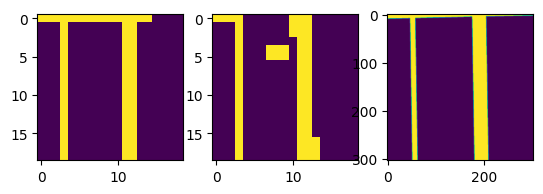

In [118]:
i = 3
plt.subplot(1, 3, 1)
plt.imshow(gt_validation_labels[i])
plt.subplot(1, 3, 2)
plt.imshow(gt_validation_predicted_labels[i].reshape(19, 19))
plt.subplot(1, 3, 3)
plt.imshow(validation_gt[i])

## Recombine the patches

In [19]:
TEST_SIZE = 50  # Size of the test data

def extract_test_data(filename, num_images):
    """Extract the images into a 4D tensor [image index, y, x, channels].
    Values are rescaled from [0, 255] down to [-0.5, 0.5].
    """
    imgs = []
    for i in range(1, num_images + 1):
        imageid = "test_" + str(i)
        image_filename = filename + imageid + "/" + imageid + ".png"
        if os.path.isfile(image_filename):
            #print("Loading " + image_filename)
            img = mpimg.imread(image_filename)
            imgs.append(img)
        else:
            print("File " + image_filename + " does not exist")
            
    return numpy.asarray(imgs)

test_data = extract_test_data("test_set_images/", TEST_SIZE)
test_data.shape

(50, 608, 608, 3)

In [20]:
# Crop the test images
first_test_data_patches = [
    test_data[i][:304, :304, :] for i in range(TEST_SIZE)
]

second_test_data_patches = [
    test_data[i][:304, 304:, :] for i in range(TEST_SIZE)
]

third_test_data_patches = [
    test_data[i][304:, :304, :] for i in range(TEST_SIZE)
]

fourth_test_data_patches = [
    test_data[i][304:, 304:, :] for i in range(TEST_SIZE)
]   

first_test_data_patches = numpy.asarray(
    first_test_data_patches
)

second_test_data_patches = numpy.asarray(
    second_test_data_patches
)

third_test_data_patches = numpy.asarray(
    third_test_data_patches
)

fourth_test_data_patches = numpy.asarray(
    fourth_test_data_patches
)

first_test_data_patches.shape

(50, 304, 304, 3)

In [53]:
first_test_predictions = model.predict(first_test_data_patches)
second_test_predictions = model.predict(second_test_data_patches)
third_test_predictions = model.predict(third_test_data_patches)
fourth_test_predictions = model.predict(fourth_test_data_patches)
first_test_predictions.shape

2/2 [==============================] - 1s 337ms/step


(50, 304, 304, 1)

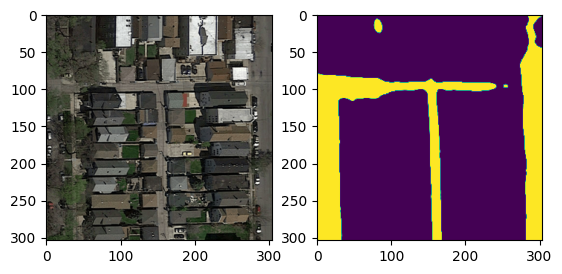

In [54]:
# Display the first image and the label
i = 5
image = test_data[i][:304, :304, :]
prediction = first_test_predictions[i]
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.subplot(1, 2, 2)
plt.imshow(prediction)

In [121]:
# Recombine the patches
first_test_predictions = first_test_predictions.reshape((TEST_SIZE, 304, 304, 1))
second_test_predictions = second_test_predictions.reshape((TEST_SIZE, 304, 304, 1))
third_test_predictions = third_test_predictions.reshape((TEST_SIZE, 304, 304, 1))
fourth_test_predictions = fourth_test_predictions.reshape((TEST_SIZE, 304, 304, 1))

first_test_predictions.shape

(50, 304, 304, 1)

In [122]:

first_gt_test_predicted_labels = model2.predict(first_test_predictions)
second_gt_test_predicted_labels = model2.predict(second_test_predictions)
third_gt_test_predicted_labels = model2.predict(third_test_predictions)
fourth_gt_test_predicted_labels = model2.predict(fourth_test_predictions)

# Combine the predictions
gt_test_predicted_labels = np.zeros((TEST_SIZE, 38, 38))

for i in range(TEST_SIZE):
    gt_test_predicted_labels[i][:19, :19] = first_gt_test_predicted_labels[i].reshape(19, 19)
    gt_test_predicted_labels[i][:19, 19:] = second_gt_test_predicted_labels[i].reshape(19, 19)
    gt_test_predicted_labels[i][19:, :19] = third_gt_test_predicted_labels[i].reshape(19, 19)
    gt_test_predicted_labels[i][19:, 19:] = fourth_gt_test_predicted_labels[i].reshape(19, 19)
    
    
gt_test_predicted_labels.shape

2/2 [==============================] - 0s 126ms/step


(50, 38, 38)

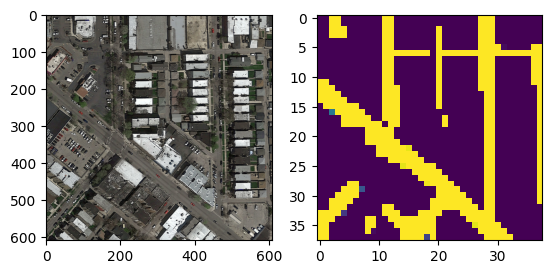

In [124]:
# Display the first image and the label
i = 4
image = test_data[i]
prediction = gt_test_predicted_labels[i]

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.subplot(1, 2, 2)
plt.imshow(prediction)

## Submission

In [128]:
# Save the predictions into a csv file
import csv
filename = "submission_double_Unet.csv"
def create_csv_submission(filename, y_pred):
    with open(filename, 'w', newline='') as csvfile:
        fieldnames = ['id', 'prediction']
        writer = csv.DictWriter(csvfile, delimiter=",", fieldnames=fieldnames)
        writer.writeheader()
        for i in range(len(gt_test_predicted_labels)):
            prediction = gt_test_predicted_labels[i]
            if i < 9:
                id = "00" + str(i + 1) + "_"
            else:
                id = "0" + str(i + 1) + "_"
            for j in range(len(prediction)):
                for k in range(len(prediction[j])):
                    writer.writerow({'id': id + str(j*16) + "_" + str(k*16), 'prediction': int(np.round(prediction[j][k]))})
                    
create_csv_submission(filename, gt_test_predicted_labels)

In [ ]:
# Export the predictions into the folders
import imageio

filename = "test_set_images/"
for i in range(1, TEST_SIZE + 1):
        img_folder = "test_" + str(i)
        imageid = "pred_" + str(i)
        image_filename = filename + img_folder + "/" + imageid + ".png"
        # Normalize the predictions to the range [0, 255] and convert to uint8
        prediction_uint8 = (gt_test_predicted_labels[i-1] * 255).astype(np.uint8)
        imageio.imwrite(image_filename, prediction_uint8)

In [ ]:
foreground_threshold = 0.25 # percentage of pixels > 1 required to assign a foreground label to a patch

# assign a label to a patch
def patch_to_label(patch):
    df = np.mean(patch)
    if df > foreground_threshold:
        return 1
    else:
        return 0
    
def mask_to_submission_strings(image_filename):
    """Reads a single image and outputs the strings that should go into the submission file"""
    img_number = int(re.search(r"\d+", image_filename).group(0))
    im = mpimg.imread(image_filename)
    patch_size = 16
    for j in range(0, im.shape[1], patch_size):
        for i in range(0, im.shape[0], patch_size):
            patch = im[i:i + patch_size, j:j + patch_size]
            label = patch_to_label(patch)
            yield("{:03d}_{}_{},{}".format(img_number, j, i, label))


def masks_to_submission(submission_filename, *image_filenames):
    """Converts images into a submission file"""
    with open(submission_filename, 'w') as f:
        f.write('id,prediction\n')
        for fn in image_filenames[0:]:
            f.writelines('{}\n'.format(s) for s in mask_to_submission_strings(fn))

In [241]:
import re

test_filenames = [
    "test_set_images/test_" + str(i) + "/test_" + str(i) + ".png" for i in range(1, TEST_SIZE + 1)
]

# Save the predictions to a submission file
submission_filename = 'Unet2_submission.csv'
masks_to_submission(submission_filename, *test_filenames)


## Alternative

In [21]:
model3 = unet_small(input_size=(304, 304, 3))

model3.summary()

Model: "U-NET"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 304, 304, 3)]     0         
                                                                 
 conv2d_27 (Conv2D)          (None, 304, 304, 8)       608       
                                                                 
 batch_normalization_25 (Ba  (None, 304, 304, 8)       32        
 tchNormalization)                                               
                                                                 
 dropout_13 (Dropout)        (None, 304, 304, 8)       0         
                                                                 
 conv2d_28 (Conv2D)          (None, 304, 304, 8)       1608      
                                                                 
 batch_normalization_26 (Ba  (None, 304, 304, 8)       32        
 tchNormalization)                                           

In [35]:
validation_data.shape, gt_train_labels.shape

((320, 304, 304, 3), TensorShape([1280, 19, 19, 1]))

In [ ]:
# Compile the model
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,     # maybe 0.001 is better
    decay_steps=60,
    decay_rate=0.95,
    staircase=True
)

# Defining optimizer
opt = keras.optimizers.Adam(learning_rate=lr_schedule)
model3.compile(
    optimizer=opt,
    loss=soft_dice_loss,        # OR loss=soft_f1_loss
    metrics=[f1_metric],
)

# Training the model
history = model3.fit(
    train_data, gt_train_labels,
    epochs=50,
    batch_size=32,
    validation_data=(validation_data, gt_validation_labels),
    verbose=1
)

Epoch 1/50
40/40 [==============================] - 68s 2s/step - loss: 0.1936 - f1_metric: 0.8081 - val_loss: 0.2822 - val_f1_metric: 0.7213
Epoch 2/50
40/40 [==============================] - 70s 2s/step - loss: 0.1841 - f1_metric: 0.8173 - val_loss: 0.2562 - val_f1_metric: 0.7449
Epoch 3/50
40/40 [==============================] - 70s 2s/step - loss: 0.1802 - f1_metric: 0.8216 - val_loss: 0.1988 - val_f1_metric: 0.8027
Epoch 4/50
40/40 [==============================] - 71s 2s/step - loss: 0.1790 - f1_metric: 0.8228 - val_loss: 0.2428 - val_f1_metric: 0.7608
Epoch 5/50
40/40 [==============================] - 74s 2s/step - loss: 0.1778 - f1_metric: 0.8237 - val_loss: 0.2836 - val_f1_metric: 0.7169
Epoch 6/50
40/40 [==============================] - 73s 2s/step - loss: 0.1734 - f1_metric: 0.8281 - val_loss: 0.3397 - val_f1_metric: 0.6600
Epoch 7/50
40/40 [==============================] - 73s 2s/step - loss: 0.1706 - f1_metric: 0.8308 - val_loss: 0.2842 - val_f1_metric: 0.7161
Epoch 

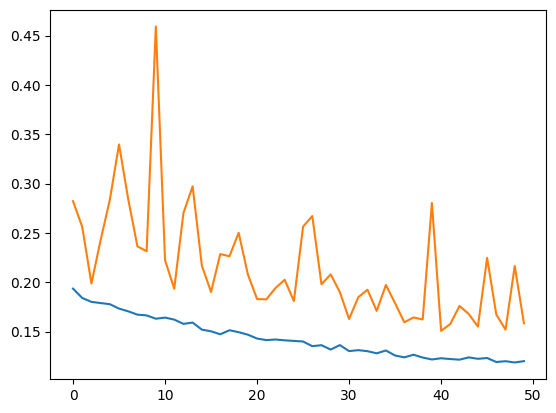

In [44]:
# Plot the loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')

In [45]:
# Predict the labels of the validation patches
gt_validation_predicted_labels = model3.predict(validation_data)
gt_train_predicted_labels = model3.predict(train_data)

40/40 [==============================] - 8s 207ms/step


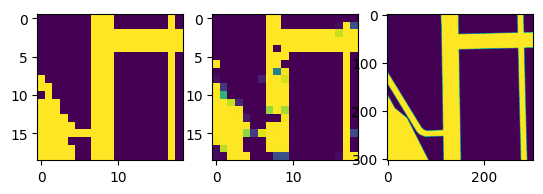

In [ ]:
i = 14
plt.subplot(1, 3, 1)
plt.imshow(gt_validation_labels[i])
plt.subplot(1, 3, 2)
plt.imshow(gt_validation_predicted_labels[i].reshape(19, 19))
plt.subplot(1, 3, 3)
plt.imshow(validation_gt[i])

In [83]:
# Augment the test data by rotating the images
rotated_test_data = np.zeros((4*TEST_SIZE, 608, 608, 3))

for i in range(TEST_SIZE):
    rotated_test_data[4*i] = test_data[i]
    rotated_test_data[4*i+1] = np.rot90(test_data[i])
    rotated_test_data[4*i+2] = np.rot90(rotated_test_data[4*i+1])
    rotated_test_data[4*i+3] = np.rot90(rotated_test_data[4*i+2])
    
# Cut the images into 304x304 patches
first_rotated_test_data_patches = [
    rotated_test_data[i][:304, :304, :] for i in range(4*TEST_SIZE)
]

second_rotated_test_data_patches = [
    rotated_test_data[i][:304, 304:, :] for i in range(4*TEST_SIZE)
]

third_rotated_test_data_patches = [
    rotated_test_data[i][304:, :304, :] for i in range(4*TEST_SIZE)
]

fourth_rotated_test_data_patches = [
    rotated_test_data[i][304:, 304:, :] for i in range(4*TEST_SIZE)
]

first_rotated_test_data_patches = numpy.asarray(
    first_rotated_test_data_patches
)

second_rotated_test_data_patches = numpy.asarray(
    second_rotated_test_data_patches
)

third_rotated_test_data_patches = numpy.asarray(
    third_rotated_test_data_patches
)

fourth_rotated_test_data_patches = numpy.asarray(
    fourth_rotated_test_data_patches
)

first_rotated_test_data_patches.shape

(200, 304, 304, 3)

In [81]:
first_gt_test_predicted_labels = model3.predict(first_rotated_test_data_patches)
second_gt_test_predicted_labels = model3.predict(second_rotated_test_data_patches)
third_gt_test_predicted_labels = model3.predict(third_rotated_test_data_patches)
fourth_gt_test_predicted_labels = model3.predict(fourth_rotated_test_data_patches)

7/7 [==============================] - 1s 156ms/step


In [85]:
# Assemble the predictions
gt_test_predicted_labels = np.zeros((4*TEST_SIZE, 38, 38))

for i in range(4*TEST_SIZE):
    gt_test_predicted_labels[i][:19, :19] = first_gt_test_predicted_labels[i].reshape(19, 19)
    gt_test_predicted_labels[i][:19, 19:] = second_gt_test_predicted_labels[i].reshape(19, 19)
    gt_test_predicted_labels[i][19:, :19] = third_gt_test_predicted_labels[i].reshape(19, 19)
    gt_test_predicted_labels[i][19:, 19:] = fourth_gt_test_predicted_labels[i].reshape(19, 19)    

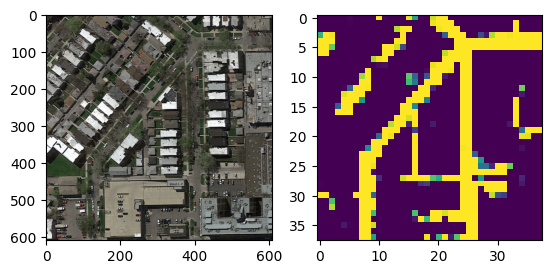

In [88]:
i = 14
plt.subplot(1, 2, 1)
plt.imshow(rotated_test_data[i])
plt.subplot(1, 2, 2)
plt.imshow(gt_test_predicted_labels[i].reshape(38, 38))

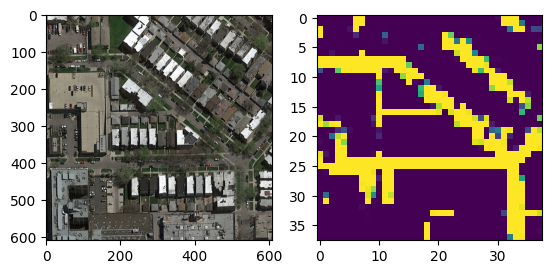

In [89]:
i = 13
plt.subplot(1, 2, 1)
plt.imshow(rotated_test_data[i])
plt.subplot(1, 2, 2)
plt.imshow(gt_test_predicted_labels[i].reshape(38, 38))

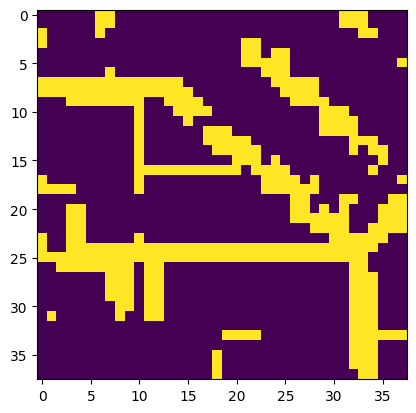

In [93]:
# Denoise the predictions, test on image 14
from skimage import morphology
from skimage import measure
from skimage.filters import threshold_otsu
from skimage.segmentation import clear_border
from skimage.measure import label, regionprops
from skimage.morphology import closing, square
from skimage.color import label2rgb
from skimage.filters import threshold_otsu

prediction = gt_test_predicted_labels[i]
otsu_threshold = threshold_otsu(gt_test_predicted_labels[14])
denoised_prediction = prediction > otsu_threshold
plt.imshow(denoised_prediction)

In [159]:
# Save the predictions into a csv file
import csv

gt_test_predicted_labels = model3.predict(test_data)

filename = "submission_single_Unet.csv"
def create_csv_submission(filename, y_pred):
    with open(filename, 'w', newline='') as csvfile:
        fieldnames = ['id', 'prediction']
        writer = csv.DictWriter(csvfile, delimiter=",", fieldnames=fieldnames)
        writer.writeheader()
        for i in range(len(gt_test_predicted_labels)):
            prediction = gt_test_predicted_labels[i]
            if i < 9:
                id = "00" + str(i + 1) + "_"
            else:
                id = "0" + str(i + 1) + "_"
            for j in range(len(prediction)):
                for k in range(len(prediction[j])):
                    writer.writerow({'id': id + str(j*16) + "_" + str(k*16), 'prediction': int(np.round(prediction[j][k]))})
                    
create_csv_submission(filename, gt_test_predicted_labels)

2/2 [==============================] - 1s 467ms/step


C:\Users\charl\AppData\Local\Temp\ipykernel_31896\1481225998.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  writer.writerow({'id': id + str(j*16) + "_" + str(k*16), 'prediction': int(np.round(prediction[j][k]))})
